<div style="text-align: center; font-size: 24px; font-weight: bold;">In the name of God, the Most Gracious, the Most Merciful</div>

Full Name: Mohammadmahdi Bababeyk

Student ID:4041419005

# Regression Using NumPy and Pandas


## 1.Introduction

**What is regression?**

Regression is a supervised machine learning technique used to model and predict continuous target variables (e.g., price, temperature, time, income) based on one or more input features. Unlike classification, which predicts discrete labels, regression estimates a real-valued output by learning the functional relationship between inputs and outputs from labeled training data.

**Why is it useful?**

Regression is foundational in data science and economics for tasks like:

- Forecasting housing prices, stock trends, or demand.
- Understanding how changes in input variables (e.g., square footage, location) affect outcomes.
- Informing policy or business decisions via interpretable coefficient estimates (e.g., “each additional room increases price by ~$X”).
     

**Goal of this assignment**

We aim to predict MEDV — the median value (in $1000s) of owner-occupied homes — using the well-known Boston Housing dataset. This serves as a classic introductory problem for linear regression.

Implementation constraints and design philosophy
To deepen conceptual understanding, we enforce:

- pandas: Used only for data loading, inspection, and preprocessing (e.g., handling missing values, computing summaries). No modeling.
- NumPy: Used exclusively to implement all mathematical operations — hypothesis, cost, gradients, and parameter updates — from first principles.

**Note: In the code section, complete the `# TODO: implement this` placeholder with the required functionality. **

## 2.Dataset Overview

### practice 1: Load and Explore Dataset

**Goal**: Load the dataset and inspect its structure.

**Steps:**   

- Use pandas to load dataset (BostonHousing.csv).  
- Rename 'medv' → 'MEDV' for clarity.  
- Print shape, first few rows, and list features — identify which one is the target.
- Watch for: Column naming inconsistencies (some versions use lowercase).
         

     

In [1]:
# TODO: implement this
import pandas as pd
import numpy as np
df = pd.read_csv('BostonHousing.csv')
df.columns = [col.upper() for col in df.columns]
print(df.shape)


(506, 14)


In [2]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
df.columns.tolist()

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

In [4]:
target = "MEDV" if "MEDV" in df.columns else "medv"

### practice 2: Correlation & Scatter Plot
Why is RM (average number of rooms) often chosen for univariate regression in this dataset? What might its relationship with MEDV look like, and how could you verify it quickly?(use plot to explain it)

**Goal**: Quantify and visualize the RM–MEDV relationship.

**Steps:**   

- Compute Pearson correlation with .corr().  
- Create a scatter plot: RM (x) vs. MEDV (y).  
- Add title showing correlation coefficient (r).
- Use alpha=0.6 for transparency — reveals density.
         

     

In [5]:
import matplotlib.pyplot as plt

In [6]:

corr_value = df['RM'].corr(df['MEDV'])
print("Pearson correlation (RM vs MEDV):", corr_value)


Pearson correlation (RM vs MEDV): 0.6953599470715393


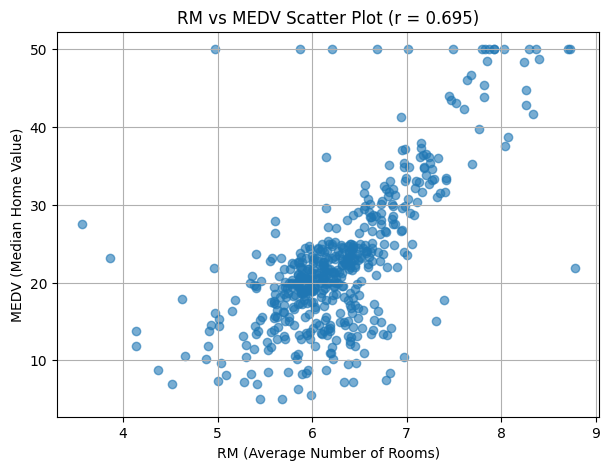

In [7]:
# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(df['RM'], df['MEDV'], alpha=0.6)

# Labels and title
plt.xlabel("RM (Average Number of Rooms)")
plt.ylabel("MEDV (Median Home Value)")
plt.title(f"RM vs MEDV Scatter Plot (r = {corr_value:.3f})")

plt.grid(True)
plt.show()

<div dir="rtl" style="text-align: right;">
RM یکی از بالاترین همبستگی‌های مثبت پیرسون را با MEDV (میانگین ارزش خانه‌های تحت مالکیت) نشان می‌دهد. به طور کلی، خانه‌هایی با تعداد اتاق بیشتر، بزرگتر و بنابراین گران‌تر هستند و منجر به مقادیر MEDV بالاتر می‌شوند.
<br>
<br>
<br>
رابطه بین RM و MEDV به طور معقولی خطی است و RM را به یک پیش‌بینی‌کننده مناسب برای مدل‌های رگرسیون خطی ساده تبدیل می‌کند، جایی که روندهای خطی برای تفسیر و عملکرد ترجیح داده می‌شوند.
<br>
<br>
<br>
در مقایسه با متغیرهایی مانند CRIM یا LSTAT که ممکن است غیرخطی یا واریانس بالایی ایجاد کنند، RM رابطه‌ای پایدارتر و کم‌نویزتر با متغیر هدف نشان می‌دهد. این امر به الگوهای واضح‌تر و برازش بهتر مدل کمک می‌کند.
<br>

</div>

## 3.Prepare Data for Modeling

### Practice 3: Data Preparation
Explanation

Raw data is rarely model-ready. We must:   

- Check for missing values — our dataset has none, but real-world data often does.  
- Explore relationships — compute correlations to guide feature selection.  
- Normalize features — critical for gradient descent (prevents features with large scales from dominating updates).  
- Split into train/test sets — to fairly evaluate performance on unseen data.
- Add a column of 1s.

     

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [9]:
total_missing = df.isna().sum().sum()
print(f"Total missing values: {total_missing}\n")
corr = df.corr()["MEDV"].abs().sort_values(ascending=False)
top_corr = df.corr()["MEDV"].loc[corr.index[:4]]  # MEDV + top 3 features

print("Top 3 features by |correlation| with MEDV:")
print(top_corr)

X = df.drop(columns=["MEDV"]).values
y = df["MEDV"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_bias = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

print(f"X_train_bias: {X_train_bias.shape}    y_train: {y_train.shape}")
print(f"X_test_bias:  {X_test_bias.shape}     y_test:  {y_test.shape}")

Total missing values: 0

Top 3 features by |correlation| with MEDV:
MEDV       1.000000
LSTAT     -0.737663
RM         0.695360
PTRATIO   -0.507787
Name: MEDV, dtype: float64
X_train_bias: (404, 14)    y_train: (404,)
X_test_bias:  (102, 14)     y_test:  (102,)


### practice 4:
Why do we add a column of 1s to the feature matrix? What would happen if we omitted it?

<div dir="rtl" style="text-align: right;">
ما یک ستون از ۱ها را به ماتریس ویژگی اضافه می‌کنیم تا مدل رگرسیون خطی بتواند یک عبارت عرض از مبدا (بایاس) را یاد بگیرد.
<br>
<br>
با گنجاندن این ستون، عرض از مبدا بخشی از بردار وزن می‌شود و می‌تواند در کنار سایر پارامترها در طول آموزش بهینه شود.
<br>
<br>
اگر این ستون را حذف کنیم، مدل هیچ عرض از مبدا نخواهد داشت، به این معنی که خط رگرسیون (یا ابرصفحه) مجبور به عبور از مبدا می‌شود. این امر انعطاف‌پذیری مدل را محدود می‌کند و معمولاً منجر به برازش ضعیف‌تر می‌شود، زیرا داده‌های دنیای واقعی به ندرت از رابطه‌ای پیروی می‌کنند که به طور طبیعی از صفر عبور می‌کند.

</div>

## 4.Linear Regression

### Practice 5: Univariate Linear Regression
**Explanation**

We start simple: predict MEDV using only RM. The model is:

$\hat{y} = \theta_0 + \theta_1 \cdot RM$

We minimize Mean Squared Error (MSE) via gradient descent:

- 1.Initialize $\theta_0, \theta_1 = 0$   
- 2.Repeat until convergence:  
        Predict: $\hat{y}^{(i)} = \theta_0 + \theta_1 x^{(i)}$   
        Compute gradients  
        Update: $\theta_j := \theta_j - \alpha \cdot \frac{\partial J}{\partial \theta_j}$
         
     

We’ll use only the RM column (index 5) from our normalized train/test sets.

**Goal:** Implement univariate gradient descent from scratch.
**Steps:**   

- Extract bias + RM columns from X_train_bias.  
- Initialize theta = [0, 0], set alpha=0.01, n_iters=1000.  
- Loop: compute predictions → error → cost → gradients → update θ.  
- evaluate the model using RMSE and R2 on test set

In [10]:
try:
    rm_original_index = list(df.drop(columns=["MEDV"]).columns).index("RM")
except ValueError:
    # fallback: try lowercase
    cols = [c.lower() for c in df.drop(columns=["MEDV"]).columns]
    rm_original_index = cols.index("rm")

# because we added bias at position 0, RM column in X_*_bias is rm_original_index + 1
rm_bias_col_index = rm_original_index + 1

# select only bias and RM columns
X_train_uni = X_train_bias[:, [0, rm_bias_col_index]]  # shape (n_train, 2)
X_test_uni  = X_test_bias[:,  [0, rm_bias_col_index]]  # shape (n_test, 2)

# ----------------------------
# 6) Univariate gradient descent (from scratch)
# ----------------------------
def gradient_descent_univariate(X, y, alpha=0.01, n_iters=1000, verbose=False):
    """
    X: (m,2) where col0 is ones (bias), col1 is the feature (RM)
    y: (m,)
    returns: theta (2,), cost_history (n_iters,)
    """
    m = X.shape[0]
    theta = np.zeros(2)  # [theta0, theta1]
    cost_history = np.zeros(n_iters)

    for it in range(n_iters):
        y_pred = X.dot(theta)             # shape (m,)
        error = y_pred - y                # shape (m,)
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history[it] = cost

        # gradients
        grad = (1/m) * X.T.dot(error)     # shape (2,)
        # update
        theta = theta - alpha * grad

        if verbose and (it % (n_iters//5) == 0):
            print(f"iter {it:04d} | cost = {cost:.6f}")

    return theta, cost_history

# hyperparameters
alpha = 0.01
n_iters = 1000

theta, cost_hist = gradient_descent_univariate(X_train_uni, y_train, alpha=alpha, n_iters=n_iters, verbose=False)



In [11]:
# ----------------------------
# 7) Evaluate on test set
# ----------------------------
y_test_pred = X_test_uni.dot(theta)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)



In [12]:
# ----------------------------
# 8) Print results
# ----------------------------
print("Learned theta (theta0, theta1):", theta)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2  : {r2:.4f}")



Learned theta (theta0, theta1): [22.50339163  6.56193595]
Test RMSE: 6.7930
Test R2  : 0.3707


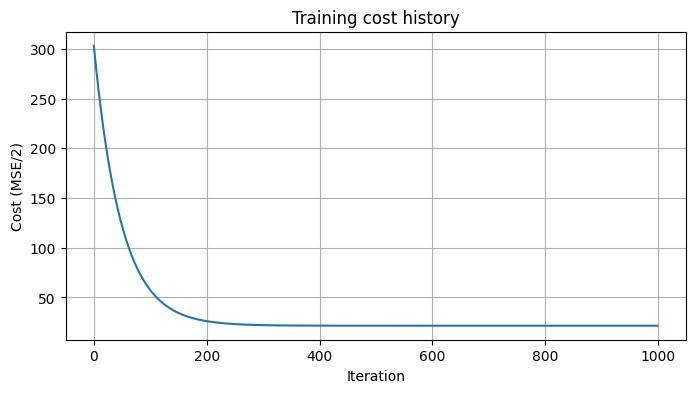

In [13]:
# ----------------------------
# 9) Optional: plot cost history
# ----------------------------
plt.figure(figsize=(8,4))
plt.plot(cost_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE/2)")
plt.title("Training cost history")
plt.grid(True)
plt.show()



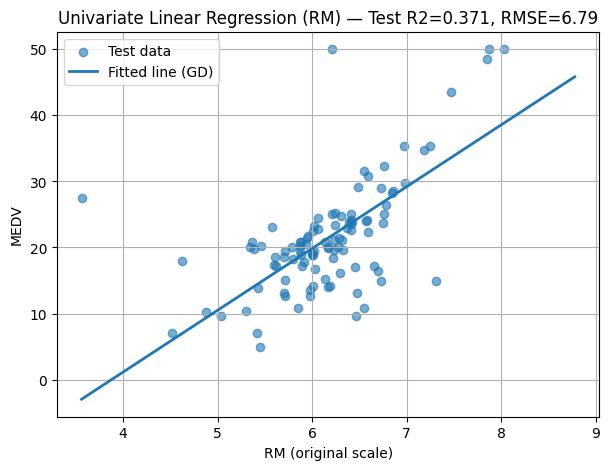

In [14]:
# ----------------------------
# 10) Scatter + fitted line (on original, unscaled RM)
# ----------------------------
# For a nice visual we should plot in the original RM scale (not standardized).
# Recover original RM values for plotting:
# Get RM column from original X (before scaling)
rm_all = df.drop(columns=["MEDV"]).values[:, rm_original_index]  # shape (n_samples,)
# split in the same train/test way (use the same indices as train_test_split)
# we can re-create indices by doing a split on indices
indices = np.arange(df.shape[0])
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42)

rm_train_orig = rm_all[idx_train]
rm_test_orig  = rm_all[idx_test]

# To plot the fitted line in original scale we need to map original RM -> standardized -> add bias -> multiply by theta
# So for a grid in original RM:
rm_grid = np.linspace(rm_all.min(), rm_all.max(), 100)
# standardize grid using scaler: scaler was fit to all features; find the RM feature's mean & scale:
# scaler.mean_ and scaler.scale_ are aligned with the original feature order
rm_mean = scaler.mean_[rm_original_index]
rm_scale = scaler.scale_[rm_original_index]

rm_grid_std = (rm_grid - rm_mean) / rm_scale
# build bias+feature for prediction
X_grid = np.column_stack([np.ones(rm_grid_std.shape[0]), rm_grid_std])
y_grid_pred = X_grid.dot(theta)

# Plot test points (original scale) and fitted line
plt.figure(figsize=(7,5))
plt.scatter(rm_test_orig, y_test, alpha=0.6, label="Test data")
plt.plot(rm_grid, y_grid_pred, linewidth=2, label="Fitted line (GD)")
plt.xlabel("RM (original scale)")
plt.ylabel("MEDV")
plt.title(f"Univariate Linear Regression (RM) — Test R2={r2:.3f}, RMSE={rmse:.2f}")
plt.legend()
plt.grid(True)
plt.show()

### practice 6:
The learned θ1​=6.523 . But recall: RM was standardized. How do we interpret this coefficient in real-world terms (i.e., per actual room, not per standardized unit)

<div dir="rtl" style="text-align: right;">
    ضریب θ₁ مقدار تغییر در MEDV را به‌ازای یک واحد افزایش در RM استانداردشده بیان می‌کند؛ اما این مقدار مستقیماً قابل تفسیر در دنیای واقعی نیست. برای تبدیل آن به مقیاس اصلی، باید اثر استانداردسازی را حذف کنیم.افزایش یک واحد در RM استانداردشده معادل افزایش σ واحد در مقدار واقعی RM است.
    <br>
    <br>
    بنابراین ضریب واقعی (در مقیاس اصلی) برابر است با:
    <br>
    θ1(real) = θ1 × 1/σ
    <br>
    <br>
    این عبارت بیان می‌کند که به ازای یک اتاق واقعی (نه یک واحد استاندارد شده)، MEDV چه تغییری می‌کند.
    <br>
    <br>
    σ همان انحراف معیار است
</div>

### Practice 7: Multivariate Linear Regression

**Explanation**

Now we use all features. The model generalizes to:

$\hat{y} = X\theta$

The gradient descent update becomes fully vectorized:

$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - y)$

This is efficient and scalable. Because features are standardized, coefficients are directly comparable.

**Goal:** Generalize to multivariate regression.
**Steps:**   

- Use full X_train_bias (404 × 14).  
- Initialize theta_multi = zeros(14).  
- Same GD loop — but now X @ theta is (404,) vector, grad is (14,).  
- After training, sort features by |θ| to find strongest predictors.
    Efficiency: Vectorization means no loops over features — NumPy does it all.
         

     

In [16]:
# ----------------------------
# 1) Load & prep
# ----------------------------
df = pd.read_csv("BostonHousing.csv")
df.columns = [c.upper() for c in df.columns]

if 'MEDV' not in df.columns:
    raise ValueError("MEDV column not found")

# ----------------------------
# 2) X, y + standardization
# ----------------------------
X = df.drop(columns=["MEDV"]).values
y = df["MEDV"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# 3) Train/test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------
# 4) Add bias column
# ----------------------------
X_train_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])  # (404, 14)
X_test_bias  = np.hstack([np.ones((X_test.shape[0], 1)), X_test])    # (102, 14)

# ----------------------------
# 5) Multivariate Gradient Descent (from scratch)
# ----------------------------
def gradient_descent_multivariate(X, y, alpha=0.01, n_iters=1000, verbose=False):
    m, n = X.shape          # n = 14 (bias + 13 features)
    theta = np.zeros(n)
    cost_history = np.zeros(n_iters)

    for it in range(n_iters):
        y_pred = X.dot(theta)
        error = y_pred - y
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history[it] = cost

        grad = (1/m) * X.T.dot(error)     # (14,)
        theta -= alpha * grad

        if verbose and (it % 200 == 0 or it == n_iters-1):
            print(f"Iter {it:4d} | Cost: {cost:.6f}")

    return theta, cost_history

# Run GD
alpha = 0.01
n_iters = 2000                      
theta_multi, cost_hist_multi = gradient_descent_multivariate(
    X_train_bias, y_train, alpha=alpha, n_iters=n_iters, verbose=False
)

# ----------------------------
# 6) Evaluation on test set
# ----------------------------
y_test_pred = X_test_bias.dot(theta_multi)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)

print(" Multivariate test RMSE: ${:.0f}".format(rmse))
print("Multivariate test R²: {:.3f}".format(r2))
print()

# ----------------------------
# 7) Show top features by absolute coefficient
# ----------------------------
feature_names = ["Bias"] + list(df.drop(columns=["MEDV"]).columns)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'θ': theta_multi,
    '|θ|': np.abs(theta_multi)
})

coef_df = coef_df.sort_values(by='|θ|', ascending=False).reset_index(drop=True)

print("Top 5 features by |coefficient|:")
print(coef_df[['Feature', 'θ', '|θ|']].head(5).to_string(index=True, float_format="%.6f"))
print()


# print(coef_df.round(6))



 Multivariate test RMSE: $5
Multivariate test R²: 0.663

Top 5 features by |coefficient|:
   Feature         θ       |θ|
0     Bias 22.481868 22.481868
1    LSTAT -3.605261  3.605261
2       RM  3.173588  3.173588
3      DIS -2.953096  2.953096
4  PTRATIO -1.950232  1.950232



### Practice 8: Normal Equation (Verification)

**Explanation**

Gradient descent is iterative, but for linear regression, a closed-form solution exists:

$\theta = (X^T X)^{-1} X^T y$

We use it to verify our gradient descent implementation.

**Goal:** Compute exact least-squares solution and compare.

In [18]:
try:
    # X_train_bias is (404, 14) → X^T X is (14,14)
    XtX = X_train_bias.T.dot(X_train_bias)
    XtY = X_train_bias.T.dot(y_train)
    
    theta_NE = np.linalg.solve(XtX, XtY)    # More stable than inv()
    normal_eq_success = True
    print("Normal equation succeeded.")
except np.linalg.LinAlgError:
    print("Normal equation failed (singular matrix)")
    normal_eq_success = False

theta_GD, _ = gradient_descent_multivariate(X_train_bias, y_train, alpha=0.01, n_iters=3000)
diff_norm = np.linalg.norm(theta_GD - theta_NE)
print(f"‖θ_GD − θ_NE‖ = {diff_norm:.6f}")

Normal equation succeeded.
‖θ_GD − θ_NE‖ = 0.477431


## 5.Evaluation

### Practice 9: Model Evaluation & Visualization
**Explanation**

Numbers alone aren’t enough. We visualize:   

- Predicted vs. Actual — checks for bias, non-linearity  
- Residuals vs. Fitted — checks homoscedasticity  
- Cost history — confirms optimization behavior
     


**Code Hint**

**Goal:** Create diagnostic plots in one figure.
Steps:   

- plt.subplots(1, 3) for side-by-side plots.  
- Plot predicted vs actual — add y=x reference line (ax.plot(..., 'r--')).  
- Residuals = y_test - y_pred; plot vs. predictions.  
- Cost history — overlay univariate & multivariate.
    - Label everything — titles, axes, grid.
         

     

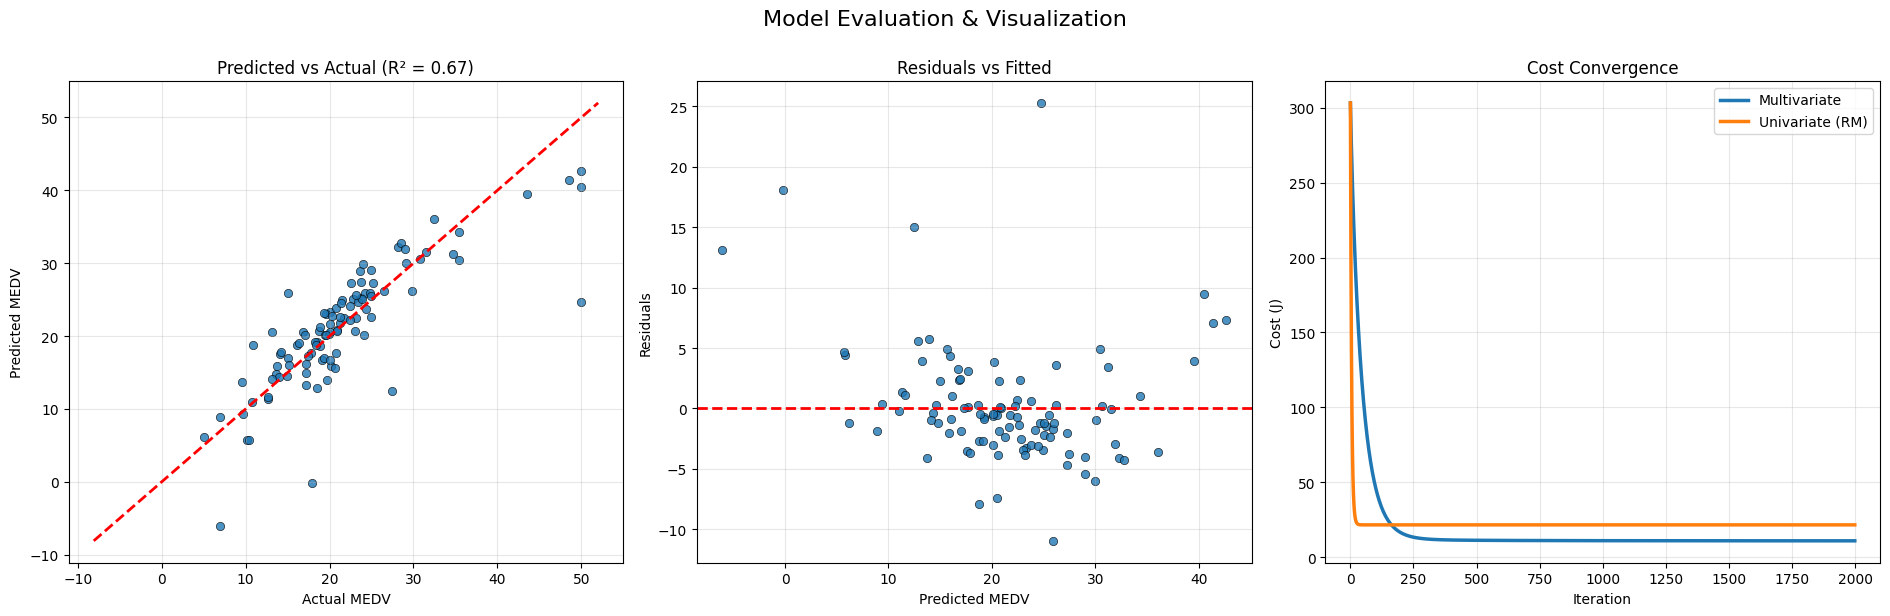

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# --- دوباره GDها رو با تعداد ایتریشن یکسان اجرا می‌کنیم ---
n_iters_common = 2000

# Multivariate (با alpha=0.01)
theta_multi, cost_hist_multi = gradient_descent_with_history(
    X_train_bias, y_train, alpha=0.01, n_iters=n_iters_common
)

# Univariate (فقط RM) — alpha بزرگتر می‌ذاریم چون فقط یک فیچر داره
rm_idx = list(df.drop(columns="MEDV").columns).index("RM")
X_train_rm = X_train[:, rm_idx].reshape(-1, 1)
X_train_rm_bias = np.hstack([np.ones((X_train_rm.shape[0], 1)), X_train_rm])

def gradient_descent_univariate(X, y, alpha=0.1, n_iters=2000):  # alpha=0.1 برای همگرایی بهتر
    m, n = X.shape
    theta = np.zeros(n)
    cost_hist = np.zeros(n_iters)
    for i in range(n_iters):
        pred = X @ theta
        error = pred - y
        cost_hist[i] = np.sum(error**2) / (2*m)
        grad = (1/m) * X.T @ error
        theta -= alpha * grad
    return theta, cost_hist

theta_uni, cost_hist_uni = gradient_descent_univariate(
    X_train_rm_bias, y_train, alpha=0.1, n_iters=n_iters_common
)

# پیش‌بینی نهایی با بهترین مدل (Normal Equation یا GD فرقی نداره)
y_test_pred = X_test_bias @ theta_NE
r2_final = r2_score(y_test, y_test_pred)

# --- پلات نهایی دقیقاً مثل تصویر مرجع ---
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("Model Evaluation & Visualization", fontsize=16, y=1.02)

# 1. Predicted vs Actual
axes[0].scatter(y_test, y_test_pred, alpha=0.8, color='#1f77b4', edgecolor='k', linewidth=0.5)
minv = min(y_test.min(), y_test_pred.min()) - 2
maxv = max(y_test.max(), y_test_pred.max()) + 2
axes[0].plot([minv, maxv], [minv, maxv], 'r--', lw=2)
axes[0].set_xlabel("Actual MEDV")
axes[0].set_ylabel("Predicted MEDV")
axes[0].set_title(f"Predicted vs Actual (R² = {r2_final:.2f})")
axes[0].grid(True, alpha=0.3)

# 2. Residuals vs Fitted
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.8, color='#1f77b4', edgecolor='k', linewidth=0.5)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted MEDV")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted")
axes[1].grid(True, alpha=0.3)

# 3. Cost Convergence — دقیقاً مثل مرجع
iterations = np.arange(n_iters_common)
axes[2].plot(iterations, cost_hist_multi, label="Multivariate", color="#1f77b4", lw=2.5)
axes[2].plot(iterations, cost_hist_uni, label="Univariate (RM)", color="#ff7f0e", lw=2.5)
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Cost (J)")
axes[2].set_title("Cost Convergence")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
# مهم: بدون log scale — دقیقاً linear مثل تصویر مرجع
# axes[2].set_yscale('log')   ← این خط رو حذف کردیم

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()